In [1]:
import pandas as pd
df = pd.read_csv("HR_Analytics_Data.csv")
df.head()


,EmployeeID,Department,Gender,Age,Education,JobRole,Salary,Experience,Attrition,PerformanceRating
0,1,HR,Female,22,Diploma,HR Manager,51131,1,No,2
1,2,Operations,Male,44,PhD,Operations Executive,177392,19,No,2
2,3,Finance,Female,34,PhD,Finance Manager,105147,3,No,2
3,4,Sales,Male,45,Diploma,Business Development Executive,141060,22,No,5
4,5,Finance,Female,52,PhD,Financial Analyst,178309,15,No,4


In [2]:
df.shape


(1000, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         1000 non-null   int64 
 1   Department         1000 non-null   object
 2   Gender             1000 non-null   object
 3   Age                1000 non-null   int64 
 4   Education          1000 non-null   object
 5   JobRole            1000 non-null   object
 6   Salary             1000 non-null   int64 
 7   Experience         1000 non-null   int64 
 8   Attrition          1000 non-null   object
 9   PerformanceRating  1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [5]:
df.describe()

,EmployeeID,Age,Salary,Experience,PerformanceRating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.890000,119433.915000,12.045000,3.003000
std,288.819436,11.025945,45607.421153,8.585726,1.437727
min,1.000000,22.000000,40321.000000,0.000000,1.000000
25%,250.750000,32.000000,81941.250000,5.000000,2.000000
50%,500.500000,41.000000,117871.000000,11.000000,3.000000
75%,750.250000,50.000000,158394.500000,18.000000,4.000000
max,1000.000000,60.000000,199852.000000,35.000000,5.000000


In [6]:
df.isnull().sum()

EmployeeID           0
Department           0
Gender               0
Age                  0
Education            0
JobRole              0
Salary               0
Experience           0
Attrition            0
PerformanceRating    0
dtype: int64

In [7]:
df['Department'].value_counts()

Department
Finance       186
Marketing     171
Sales         170
Operations    165
HR            158
IT            150
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      501
Female    499
Name: count, dtype: int64

In [9]:
df['Attrition'].value_counts()

Attrition
No     861
Yes    139
Name: count, dtype: int64

In [10]:
df['Salary'].mean()

np.float64(119433.915)

In [11]:
df.groupby('Department')['Salary'].mean().sort_values(ascending=False)

Department
Operations    123824.739394
Finance       122695.032258
IT            120922.580000
Marketing     118873.935673
Sales         116158.135294
HR            113726.860759
Name: Salary, dtype: float64

In [12]:
df.groupby('Gender')['Salary'].mean()

Gender
Female    119996.939880
Male      118873.137725
Name: Salary, dtype: float64

In [13]:
df['PerformanceRating'].value_counts().sort_index()

PerformanceRating
1    201
2    214
3    180
4    191
5    214
Name: count, dtype: int64

In [14]:
df.groupby('Department')['Experience'].mean()

Department
Finance       11.962366
HR            11.854430
IT            12.586667
Marketing     11.625731
Operations    12.218182
Sales         12.088235
Name: Experience, dtype: float64

In [15]:
df.nlargest(10, 'Salary')

,EmployeeID,Department,Gender,Age,Education,JobRole,Salary,Experience,Attrition,PerformanceRating
133,134,IT,Male,55,Bachelor,System Administrator,199852,20,No,1
326,327,Operations,Male,58,Master,Coordinator,199818,1,No,3
620,621,Marketing,Female,26,Diploma,Marketing Specialist,199728,5,No,2
233,234,Sales,Male,32,PhD,Sales Manager,199556,6,No,4
144,145,Sales,Female,37,Bachelor,Business Development Executive,199466,0,Yes,1
38,39,Operations,Male,27,Master,Operations Manager,199434,6,No,1
313,314,Operations,Male,52,Master,Coordinator,199050,24,No,5
753,754,IT,Female,45,Master,Software Engineer,198965,24,Yes,5
186,187,Finance,Male,42,Master,Accountant,198778,5,No,1
176,177,IT,Female,51,Bachelor,Software Engineer,198673,8,No,5


In [16]:
df[['Age','Salary','Experience','PerformanceRating']].corr()

,Age,Salary,Experience,PerformanceRating
Age,1.000000,0.051684,0.515643,0.059314
Salary,0.051684,1.000000,0.030750,0.037694
Experience,0.515643,0.030750,1.000000,0.006963
PerformanceRating,0.059314,0.037694,0.006963,1.000000


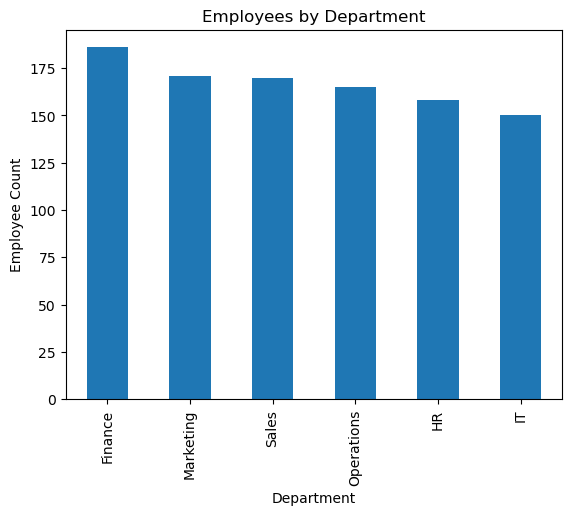

In [17]:
import matplotlib.pyplot as plt

df['Department'].value_counts().plot(kind='bar')
plt.title('Employees by Department')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.show()

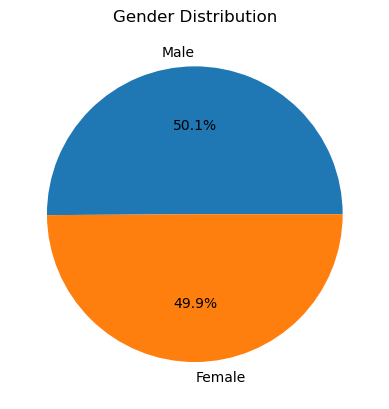

In [18]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Gender Distribution')
plt.show()

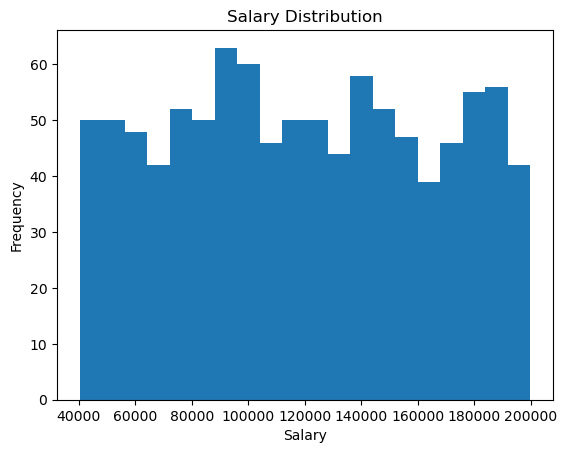

In [19]:
plt.hist(df['Salary'], bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

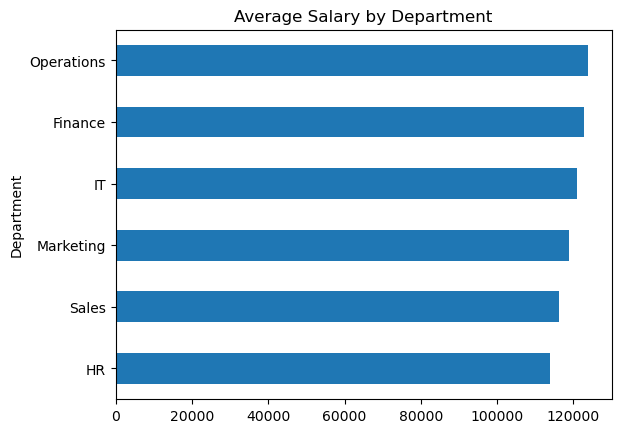

In [20]:
df.groupby('Department')['Salary'].mean().sort_values().plot(kind='barh')
plt.title('Average Salary by Department')
plt.show()

In [21]:
pip install pyodbc sqlalchemy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(
    "mssql+pyodbc://@DESKTOP-F06SJHM\\SQLEXPRESS/HR_Analytics?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

print("Connected Successfully!")

Connected Successfully!
